In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
df["FamSize"] = df['SibSp'] + df['Parch'] + 1
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20100\991558219.py:1: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamSize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1


In [4]:
df = df.drop(columns = ['Cabin', 'Name', 'SibSp', 'Parch'])


In [5]:
df = df.drop(columns = ['Ticket'])

In [6]:
df['Age'] = df['Age'].fillna(
    df.groupby("Title")["Age"].transform("median")
)

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns = ["PassengerId"])
df = pd.get_dummies(df, columns = ['Sex', 'Embarked', 'Title'], drop_first= True)
df = df.astype(int)
df['Fare'] = np.log1p(df['Fare'])


In [7]:
df.head()

,Survived,Pclass,Age,Fare,FamSize,Sex_male,Embarked_Q,Embarked_S,Title_Col,Title_Countess,...,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir
0,0,3,22,2.079442,2,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1,1,38,4.276666,2,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,1,3,26,2.079442,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1,1,35,3.988984,2,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,3,35,2.197225,1,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0


In [8]:
X_train = df.drop(columns = 'Survived', axis = 1)
y_train = df['Survived']

# Logistic

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline(steps = [
    ('classifier', LogisticRegression(solver = 'liblinear'))
])

In [10]:
pipe.fit(X_train, y_train)

,steps,"[('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None


# 

## KNN

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
scaler = StandardScaler()

In [12]:
X_train_scaled = scaler.fit_transform(X_train)

In [13]:
model_knn = KNeighborsClassifier(n_neighbors = 11)

In [14]:
model_knn.fit(X_train_scaled, y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# Test Data

In [15]:
test_df = pd.read_csv("test.csv")

In [16]:
test = pd.read_csv("test.csv")

In [17]:
test_df["Title"] = test_df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
test_df["FamSize"] = test_df['SibSp'] + test_df['Parch'] + 1


<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20100\3404564092.py:1: SyntaxWarning: invalid escape sequence '\.'
  test_df["Title"] = test_df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


In [18]:

test_df = test_df.drop(columns = ['Cabin', 'Name', 'SibSp', 'Parch'])
test_df = test_df.drop(columns = ['Ticket'])
test_df["Age"] = test_df["Age"].fillna(df["Age"].median())


test_df["Fare"] = test_df["Fare"].fillna(df["Fare"].median())

test_df["Embarked"] = test_df["Embarked"].fillna(test_df["Embarked"].mode()[0])
test_df = test_df.drop(columns = ["PassengerId"])
test_df = pd.get_dummies(test_df, columns = ['Sex', 'Embarked', 'Title'], drop_first= True)


In [19]:
test_df.isna().sum()

Pclass          0
Age             0
Fare            0
FamSize         0
Sex_male        0
Embarked_Q      0
Embarked_S      0
Title_Dona      0
Title_Dr        0
Title_Master    0
Title_Miss      0
Title_Mr        0
Title_Mrs       0
Title_Ms        0
Title_Rev       0
dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

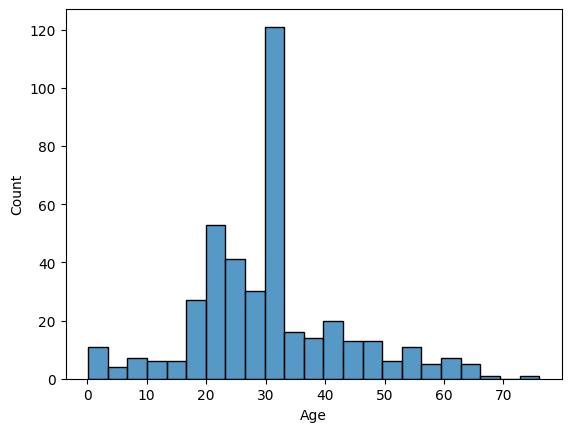

In [20]:
sns.histplot((test_df['Age']))

In [21]:
test_df = test_df.astype(int)
test_df['Fare'] = np.log1p(test_df['Fare'])

In [22]:
test_df = test_df.reindex(columns=X_train.columns, fill_value=0)

In [23]:
y_pred = pipe.predict(test_df)

In [24]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": y_pred
})
print(submission)

     PassengerId  Survived
0            892         0
1            893         1
2            894         0
3            895         0
4            896         1
..           ...       ...
413         1305         0
414         1306         1
415         1307         0
416         1308         0
417         1309         1

[418 rows x 2 columns]


In [25]:
submission.to_csv(r"C:\Users\LENOVO\Downloads\submission4.csv", index=False)

# KNN

In [26]:
test_df_scaled = scaler.fit_transform(test_df)
y_pred_scaled = model_knn.predict(test_df_scaled)

In [27]:
submission_knn = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": y_pred_scaled
})

In [28]:
submission_knn.to_csv(r"C:\Users\LENOVO\Downloads\submission_knn.csv", index=False)

# Decision Tree

## xgboost, random forest and lightgbm

In [29]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, verbosity = -1)
lgbm_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [30]:
test_df_aligned = test_df.reindex(columns=X_train.columns, fill_value=0)

In [31]:
rf_preds = rf_model.predict(test_df_aligned)
xgb_preds = xgb_model.predict(test_df_aligned)
lgbm_preds = lgbm_model.predict(test_df_aligned)

In [32]:
sub_rf = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': rf_preds})
sub_rf.to_csv(r"C:\Users\LENOVO\Downloads\submission_rf.csv", index=False)

sub_xgb = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': xgb_preds})
sub_xgb.to_csv(r"C:\Users\LENOVO\Downloads\submission_xgb.csv", index=False)

sub_lgbm = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': lgbm_preds})
sub_lgbm.to_csv(r"C:\Users\LENOVO\Downloads\submission_lgbm.csv", index=False)